# 내일 비가 올지 예측해보기 (Rain in Australia) 
- 랜덤 포레스트(Random Forest) 이용
- Outlier 제거로 성능 향상시켜 보기

### Outlier 제거
<img src="https://miro.medium.com/max/18000/1*2c21SkzJMf3frPXPAR_gZA.png">


# baseline 성능
3-5-1_Random_Forest로_내일_비가올지_예측해보기 (Rain in Australia).ipynb 
#### baseline - 랜덤 포레스트(Random Forest) 
#### accuracy : 0.86, precision : 0.87,  recall : 0.73, f1-score : 0.76

In [1]:
# 불필요한 경고 출력을 방지
import warnings
warnings.filterwarnings('ignore')

## 관련 라이브러리 import

In [2]:
# 데이터 처리, 그래프, 수치 계산에 필요한 라이브러리를 불러옴
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# 데이터 로딩 

In [3]:
# 호주 날씨 CSV 파일을 DataFrame으로 불러옴
df = pd.read_csv('datas_ml/weatherAUS.csv')
print(df.shape)

(145460, 23)


# EDA 및 데이터 전처리

## 데이터 형상 파악하기

In [4]:
# 데이터의 앞 5행을 보며 열 구조와 값을 확인
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
# 열 이름, 자료형, 결측치 여부를 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [6]:
# 숫자형 열의 평균, 표준편차, 최솟값, 최댓값 등 기초 통계를 확인
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


<Axes: xlabel='RainTomorrow', ylabel='count'>

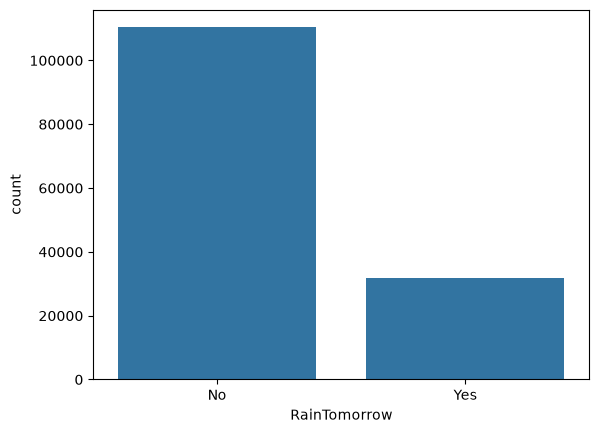

In [7]:
# 내일 비가 옴(Yes)과 오지 않음(No)의 개수를 막대그래프로 비교
sns.countplot(x="RainTomorrow", data=df)

In [8]:
# 숫자형이 아닌 범주형(문자열) 열의 이름만 선택
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [9]:
# 범주형 열 목록과 고유값 개수, 최빈값 등을 확인
print(cat_cols)
df[cat_cols].describe()

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## 상관 분석(Correlation Analysis) 수행해보기

In [10]:
# 상관관계와 이상치를 분석할 숫자형 열만 선택
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

In [11]:
# 원본 df를 보존하면서 상관관계 분석용 데이터를 복사
temp_df = df[num_cols].copy()
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


In [12]:
# 상관관계 분석용 데이터의 (행 수, 열 수)를 확인
temp_df.shape

(145460, 16)

In [13]:
# Yes/No 문자열을 0/1 숫자로 바꾸어 상관관계를 계산할 수 있게 함
temp_df['RainToday'] = df['RainToday'].replace({'No': 0, 'Yes': 1})
temp_df['RainTomorrow'] = df['RainTomorrow'].replace({'No': 0, 'Yes': 1})

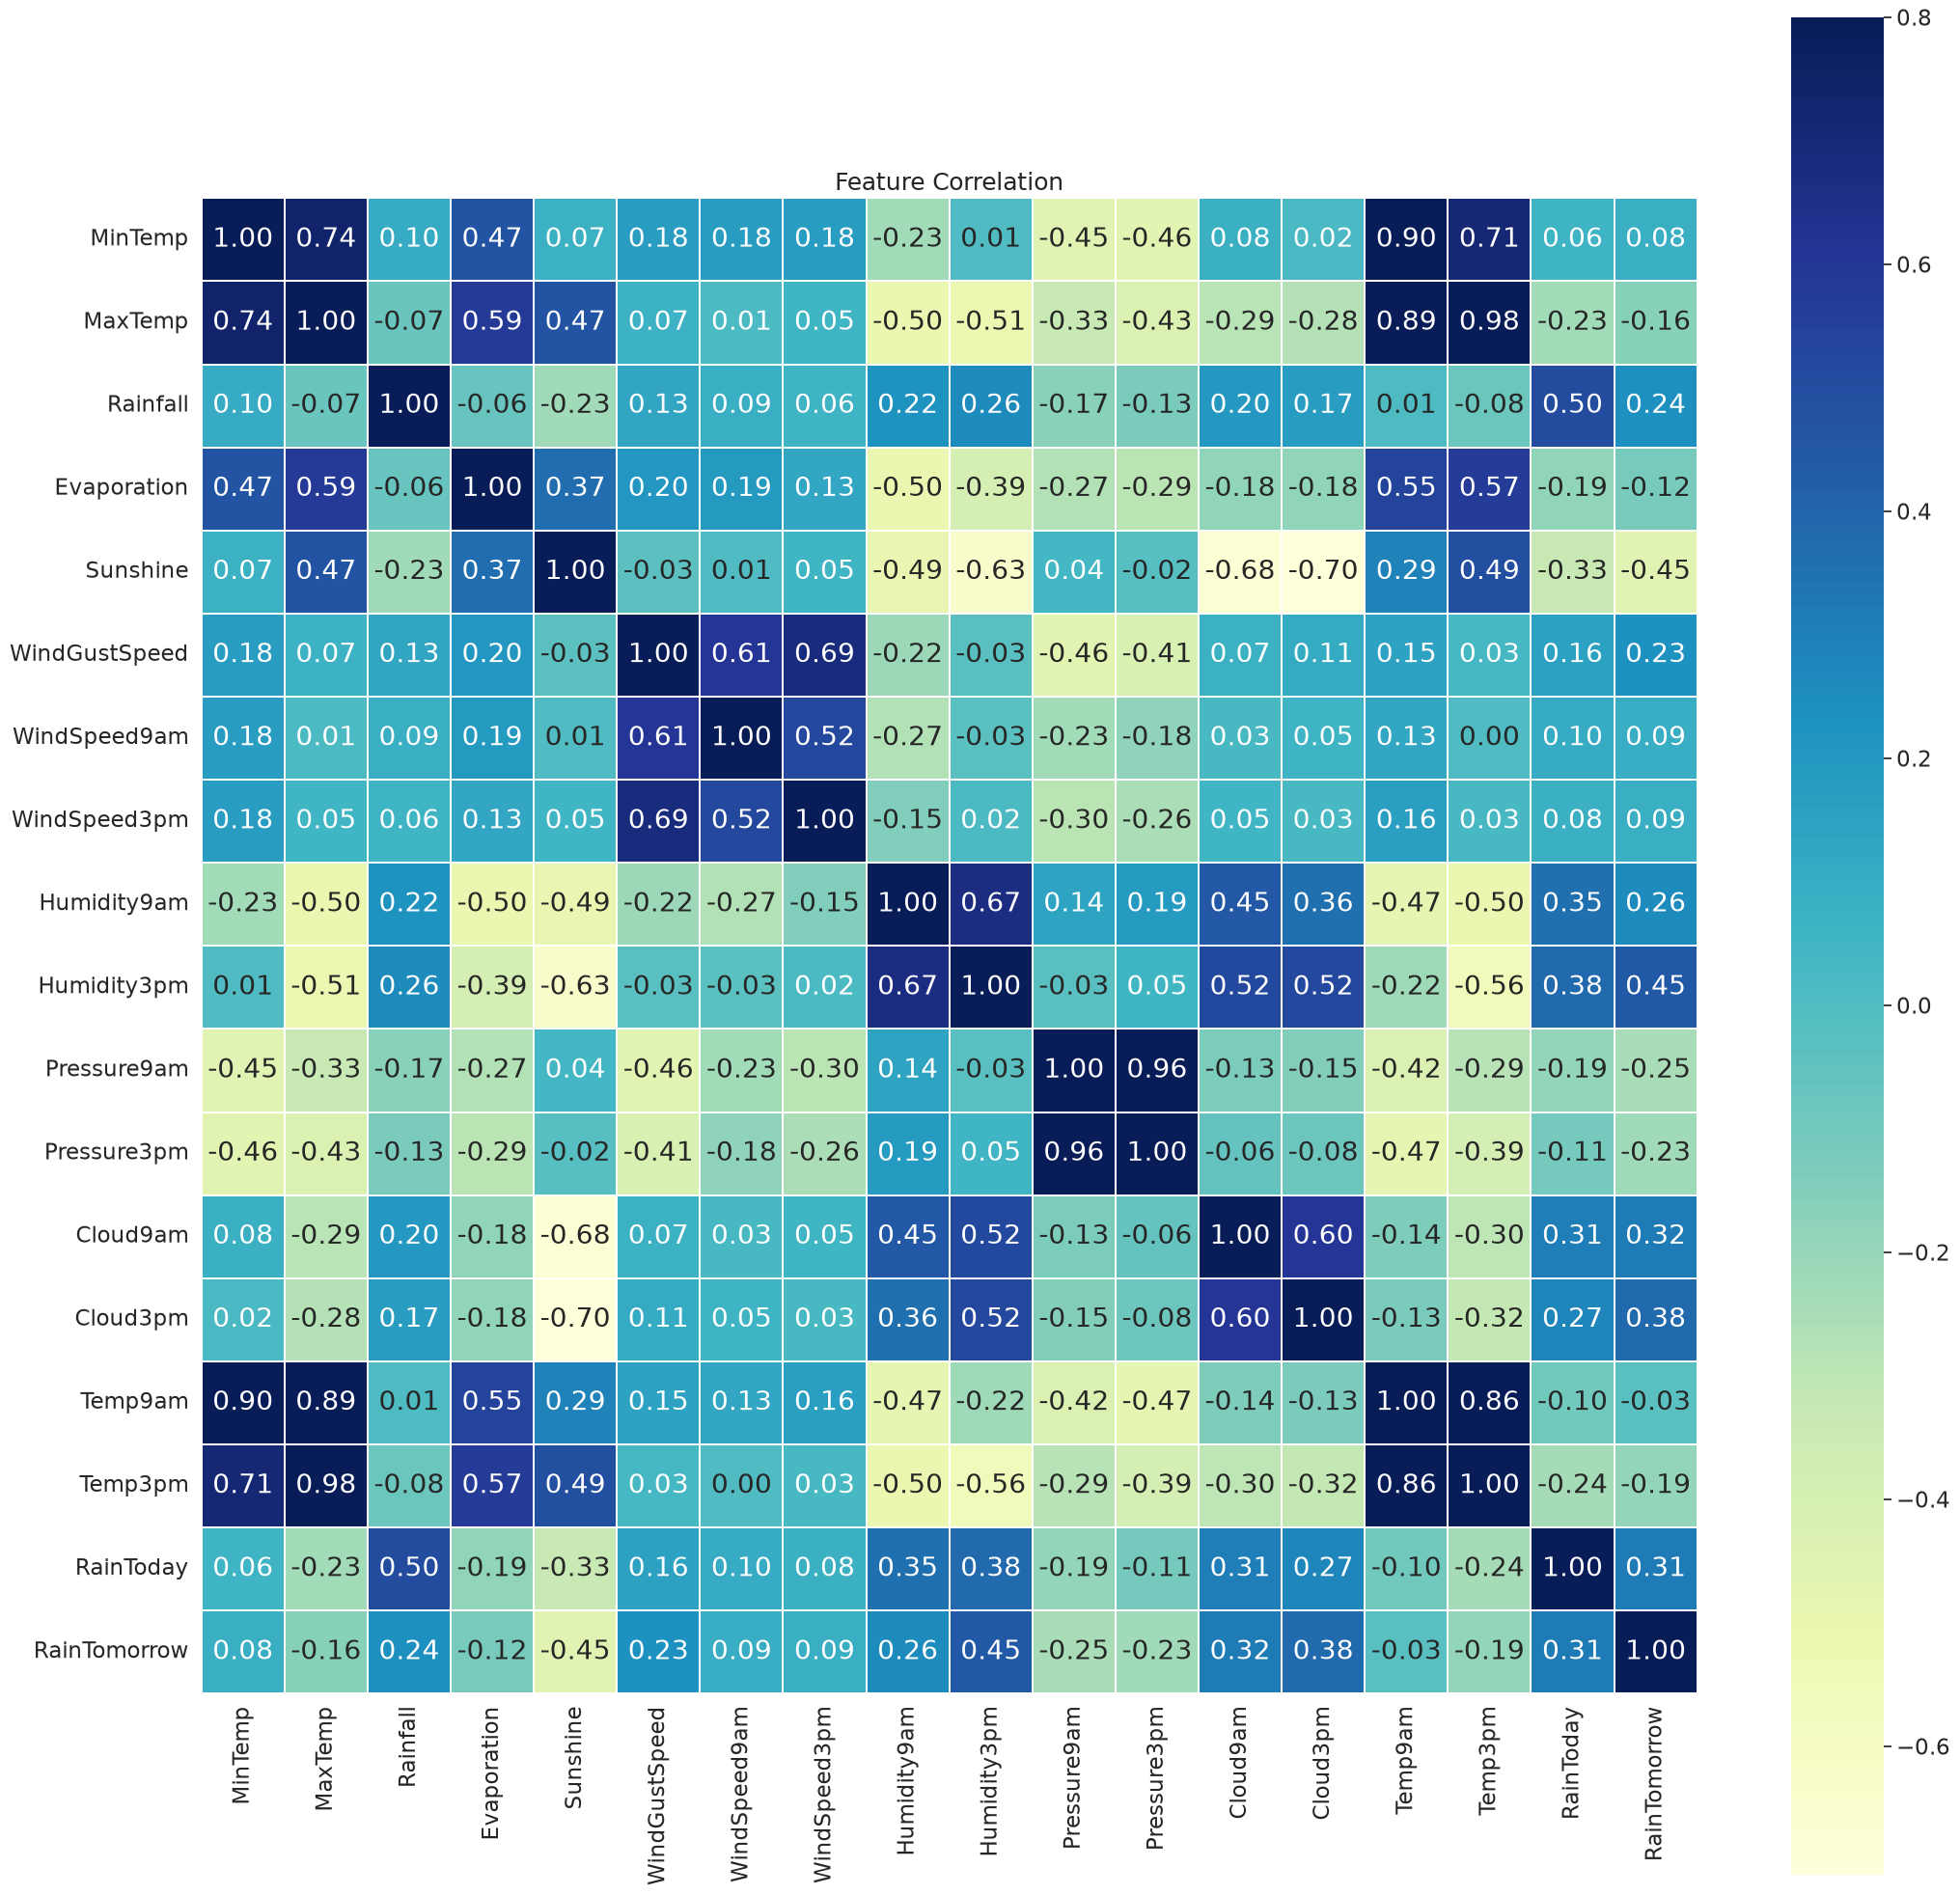

In [14]:
# 숫자형 변수 간의 상관계수(-1~1)를 계산하고 히트맵으로 표현
corr = temp_df.corr()
plt.figure(figsize=(25, 25));
sns.set(font_scale=1.5); # plot의 글자크기 설정
sns.heatmap(corr,
            vmax=0.8,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 20},  # annot 글자크기
            cmap='YlGnBu');
plt.title('Feature Correlation');

In [15]:
# 상관관계를 계산한 특징 열 목록을 확인
corr.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

In [16]:
# RainTomorrow와 상관관계가 있는 feature 살펴보기
# Rainfall,'Evaporation', Sunshine, WindGustSpeed','Humidity9am', ' 'Pressure9am', 
# 'Pressure3pm', Cloud9am, Cloud3pm

## Outlier 분석

<Axes: ylabel='Sunshine'>

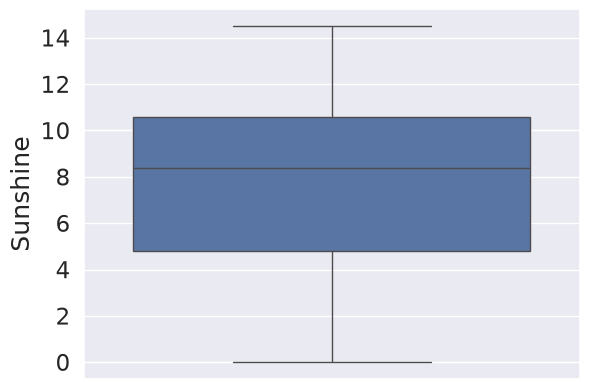

In [17]:
# 일조 시간(Sunshine)의 분포와 이상치를 박스플롯으로 확인
sns.boxplot(data=df, y='Sunshine')

In [18]:
# 이상치 제거 전 원본 데이터의 크기를 확인
df.shape

(145460, 23)

### categorical / numerical column 리스트 추출

In [19]:
# 앞에서 선택한 범주형 열 목록을 확인
print(cat_cols)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


In [20]:
# 박스플롯으로 확인할 숫자형 열 목록을 확인
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


### [문제해결] 숫자형 컬럼을 boxplot()으로 시각화

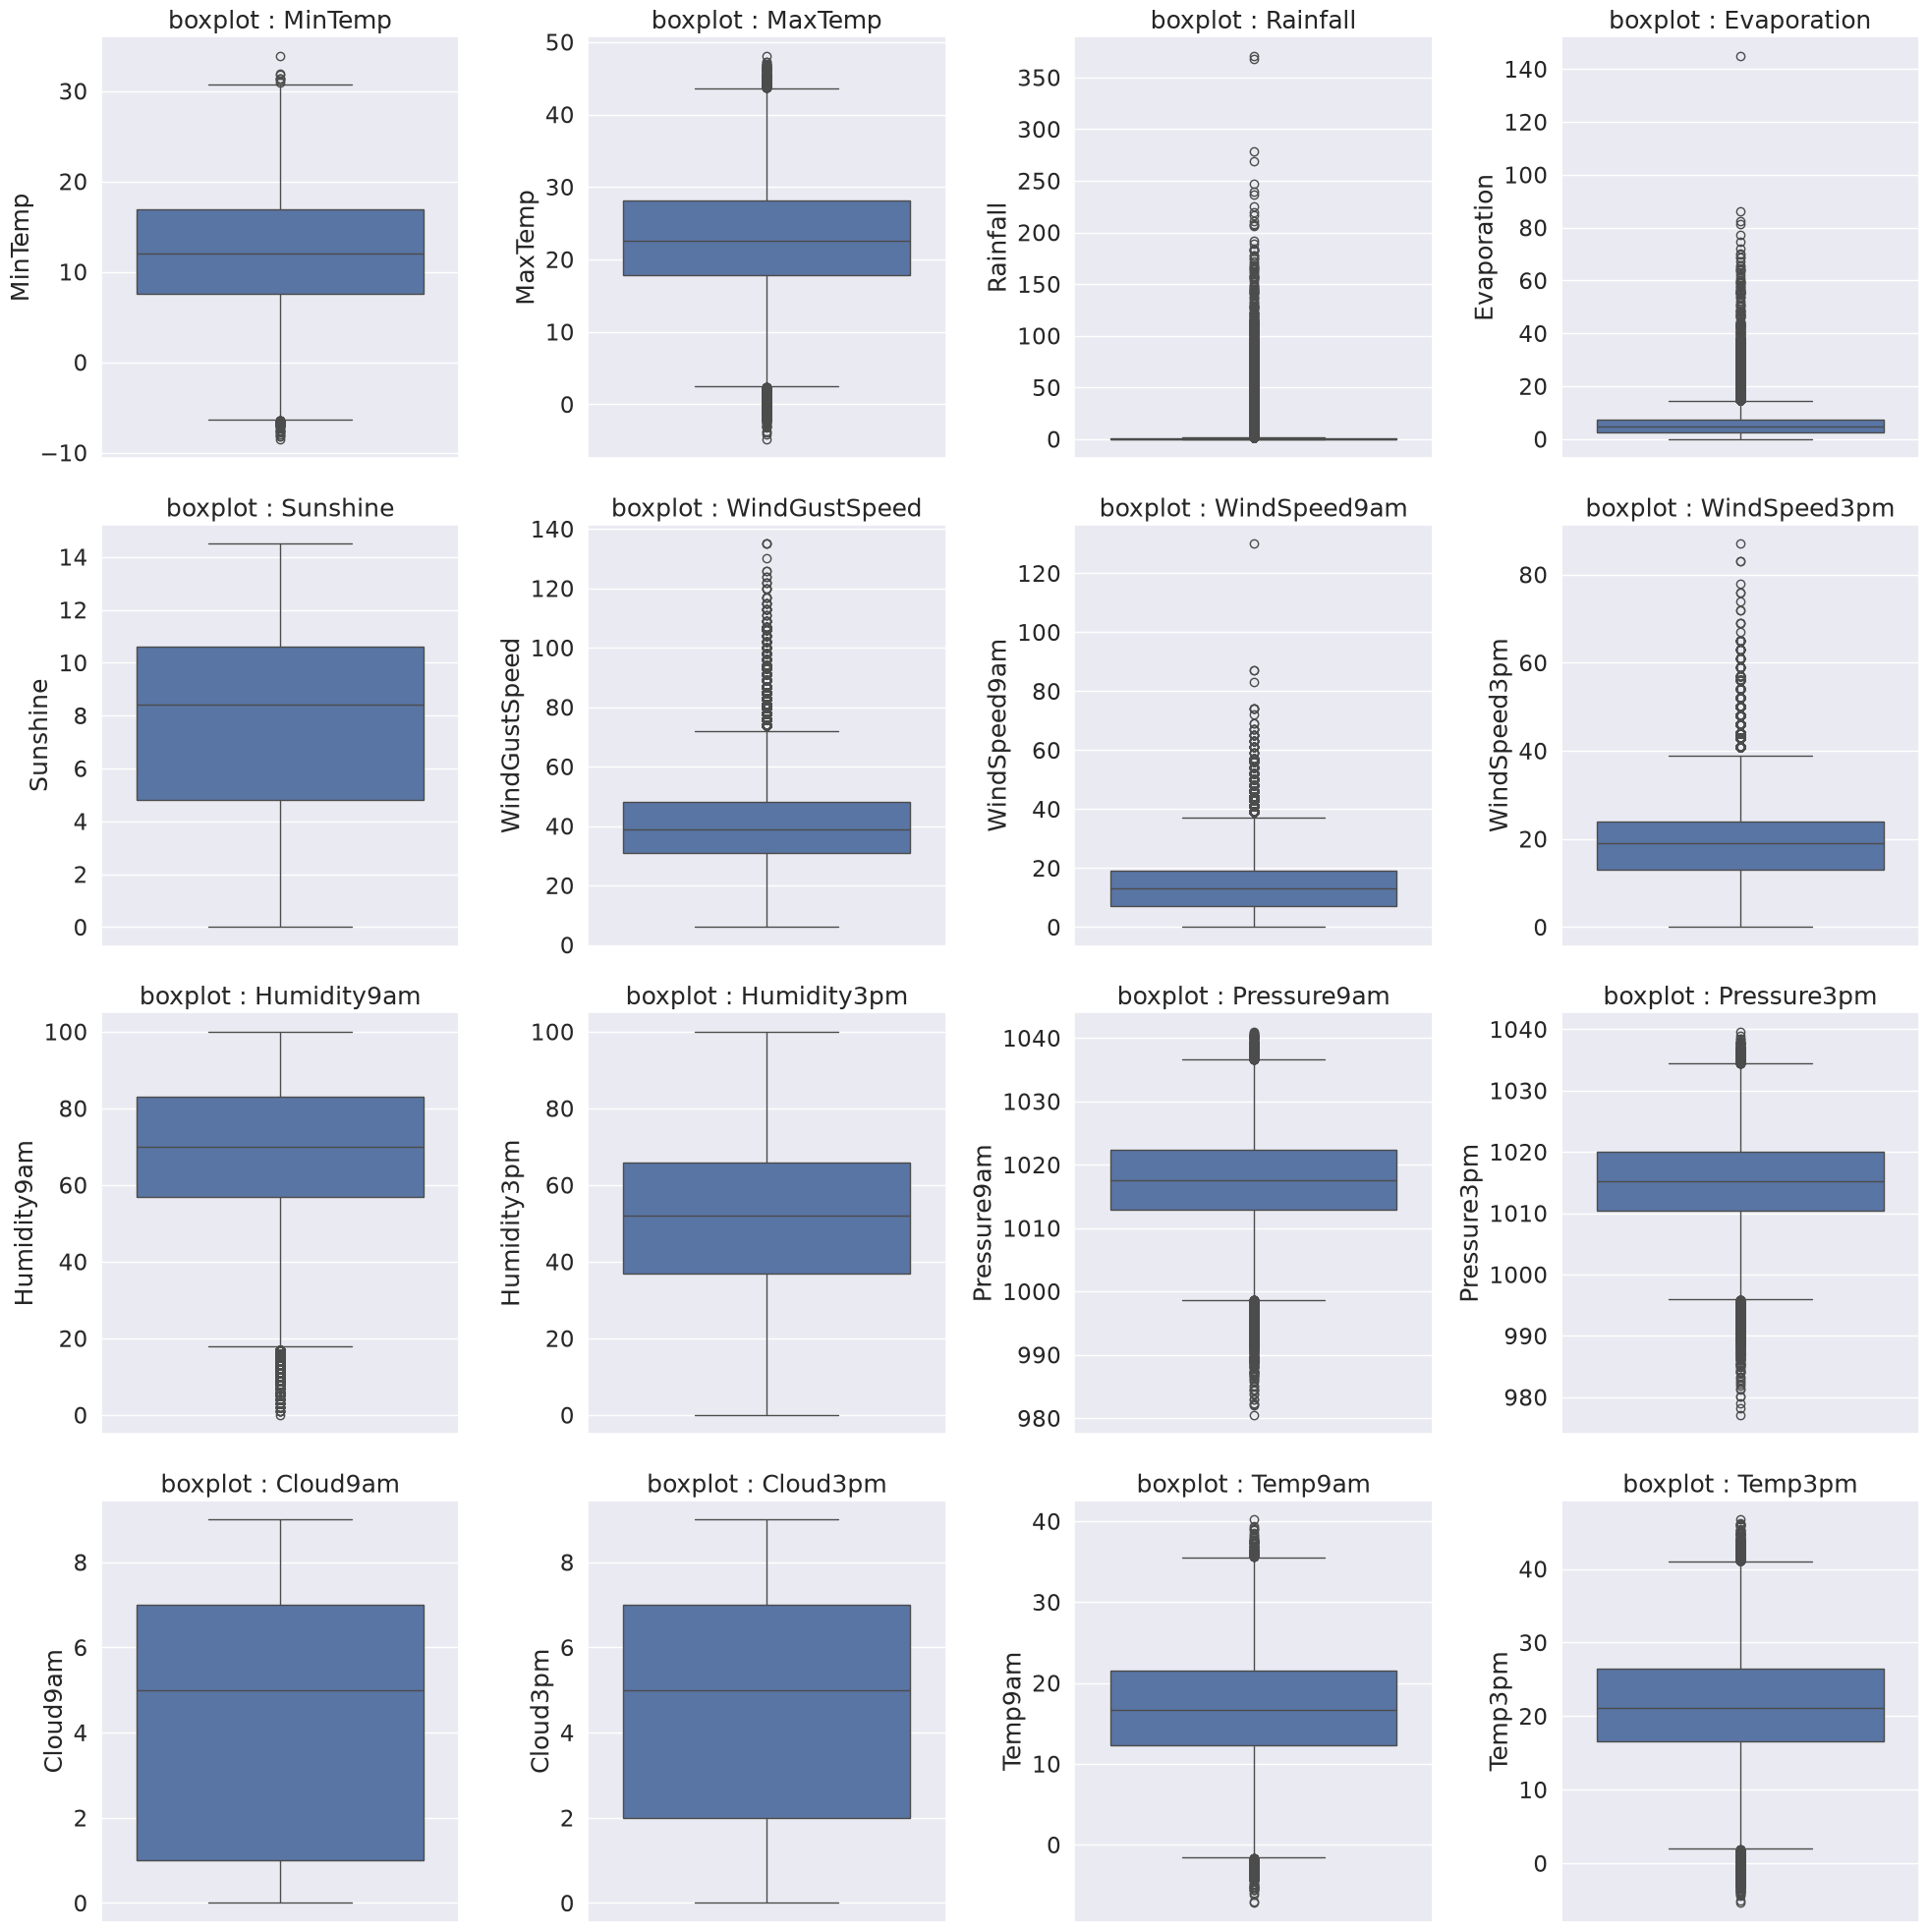

In [21]:
# [문제] 4x4 fig로 각 fearture들 데이터 분포, 이상치 확인

# 16개의 숫자형 특징을 보기 위해 4행 4열의 그래프 영역을 생성
nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20, 20)

# 2차원 축 배열을 1차원으로 바꾸어 반복문에서 순서대로 사용
axs = axs.flatten()
for i, col in enumerate(num_cols):
    # 각 숫자형 열을 박스플롯으로 그려 분포와 이상치를 확인
    sns.boxplot(data=df, y=col, ax=axs[i])
    axs[i].set_title('boxplot : ' + col)

plt.tight_layout()

In [22]:
# 강수량(Rainfall)의 최댓값을 확인
df['Rainfall'].max()

np.float64(371.0)

In [23]:
# 강수량의 평균을 확인
df['Rainfall'].mean()

np.float64(2.360918149916666)

In [24]:
# 이상치의 영향을 덜 받는 강수량 중앙값을 확인
df['Rainfall'].median()

np.float64(0.0)

In [25]:
# 강수량이 0인 행을 제외하기 전의 크기를 확인
df.shape

(145460, 23)

### Rainfall 컬럼에서 0이 아닌것만 필터링 

In [ ]:
# 비가 오지 않은 날(0.0)은 이상치 계산에서 제외하기 위해 별도로 필터링
# query() : 조건에 맞는 행만 골라냄
filtered_rainfall = df.query('Rainfall != 0.0').copy()

In [27]:
# 강수량이 0이 아닌 데이터의 크기를 확인
filtered_rainfall.shape

(54380, 23)

In [28]:
# 필터링 후에도 유지된 원본 행 인덱스를 확인
filtered_rainfall.index

Index([     0,      4,      5,      9,     11,     12,     13,     15,     17,
           18,
       ...
       145323, 145324, 145325, 145326, 145336, 145391, 145392, 145393, 145394,
       145429],
      dtype='int64', length=54380)

In [29]:
# 강수량이 0이 아닌 데이터의 처음 3행을 확인
filtered_rainfall.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No


### 이상치 확인하는 함수

In [30]:
# 앞의 탐색 과정에서 생긴 변경을 초기화하고 원본 데이터를 다시 불러옴
df = pd.read_csv('datas_ml/weatherAUS.csv')
print(df.shape)

(145460, 23)


In [ ]:
# IQR(사분위수 범위) 기준으로 여러 열의 이상치 행 인덱스를 찾는 함수
def get_outlier_indices(data, columns):
    outlier_indices = []   # 이상치에 해당하는 행의 목록 리스트
    for column in columns:
        # 해당 컬럼의 IQR 계산
        Q1 = data[column].quantile(0.25) # 25%분위수(1Q)
        Q3 = data[column].quantile(0.75) # 75%분위수(3Q)
        IQR = Q3 - Q1

        # 최소값
        min_value = Q1 - 1.5*IQR
        # 최대값
        max_value = Q3 + 1.5*IQR

        # 이상치의 인덱스를 추출하기 위한 필터
        filter = ((data[column] < min_value) | (data[column] > max_value))  

        # 필터를 적용해 이상치를 추출
        outlier_data = data[column][filter]
        # 해당 컬럼의 이상치 데이터의 index
        outlier_index = outlier_data.index
        # index 리스트를 outlier_indices에 추가함
        outlier_indices.extend(outlier_index)

    # 처리한 모든 컬럼의 이상치의 인덱스를 리턴함
    return outlier_indices

In [32]:
# 강수량 이상치를 제거하기 전의 데이터 크기를 출력
print('dataframe before removing outlier (Rainfall column) :', df.shape)
delete_indices = get_outlier_indices(filtered_rainfall, ['Rainfall'])
# print(delete_indices)

dataframe before removing outlier (Rainfall column) : (145460, 23)


In [ ]:
# reset_index(drop=True) : df의 index를 reset 할 때, 원래 인덱스가 컬럼으로 추가되지 않도록 삭제함
df = df.drop(delete_indices, axis=0).reset_index(drop=True)
print('dataframe after removing outlier (Rainfall column) :', df.shape)

dataframe after removing outlier (Rainfall column) : (140240, 23)


In [34]:
# 다른 주요 날씨 특징의 이상치 행 인덱스를 한번에 찾음
print('dataframe before removing outlier (etc) :', df.shape)
delete_indices = get_outlier_indices(df, ['Humidity9am','Evaporation', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm'])


dataframe before removing outlier (etc) : (140240, 23)


In [35]:
# 주요 날씨 특징의 이상치 행을 제거하고 인덱스를 다시 정리
df = df.drop(delete_indices, axis=0).reset_index(drop=True)
print('dataframe after removing outlier (etc) :', df.shape)

dataframe after removing outlier (etc) : (133529, 23)


### 이상치 제거후 boxplot으로 확인

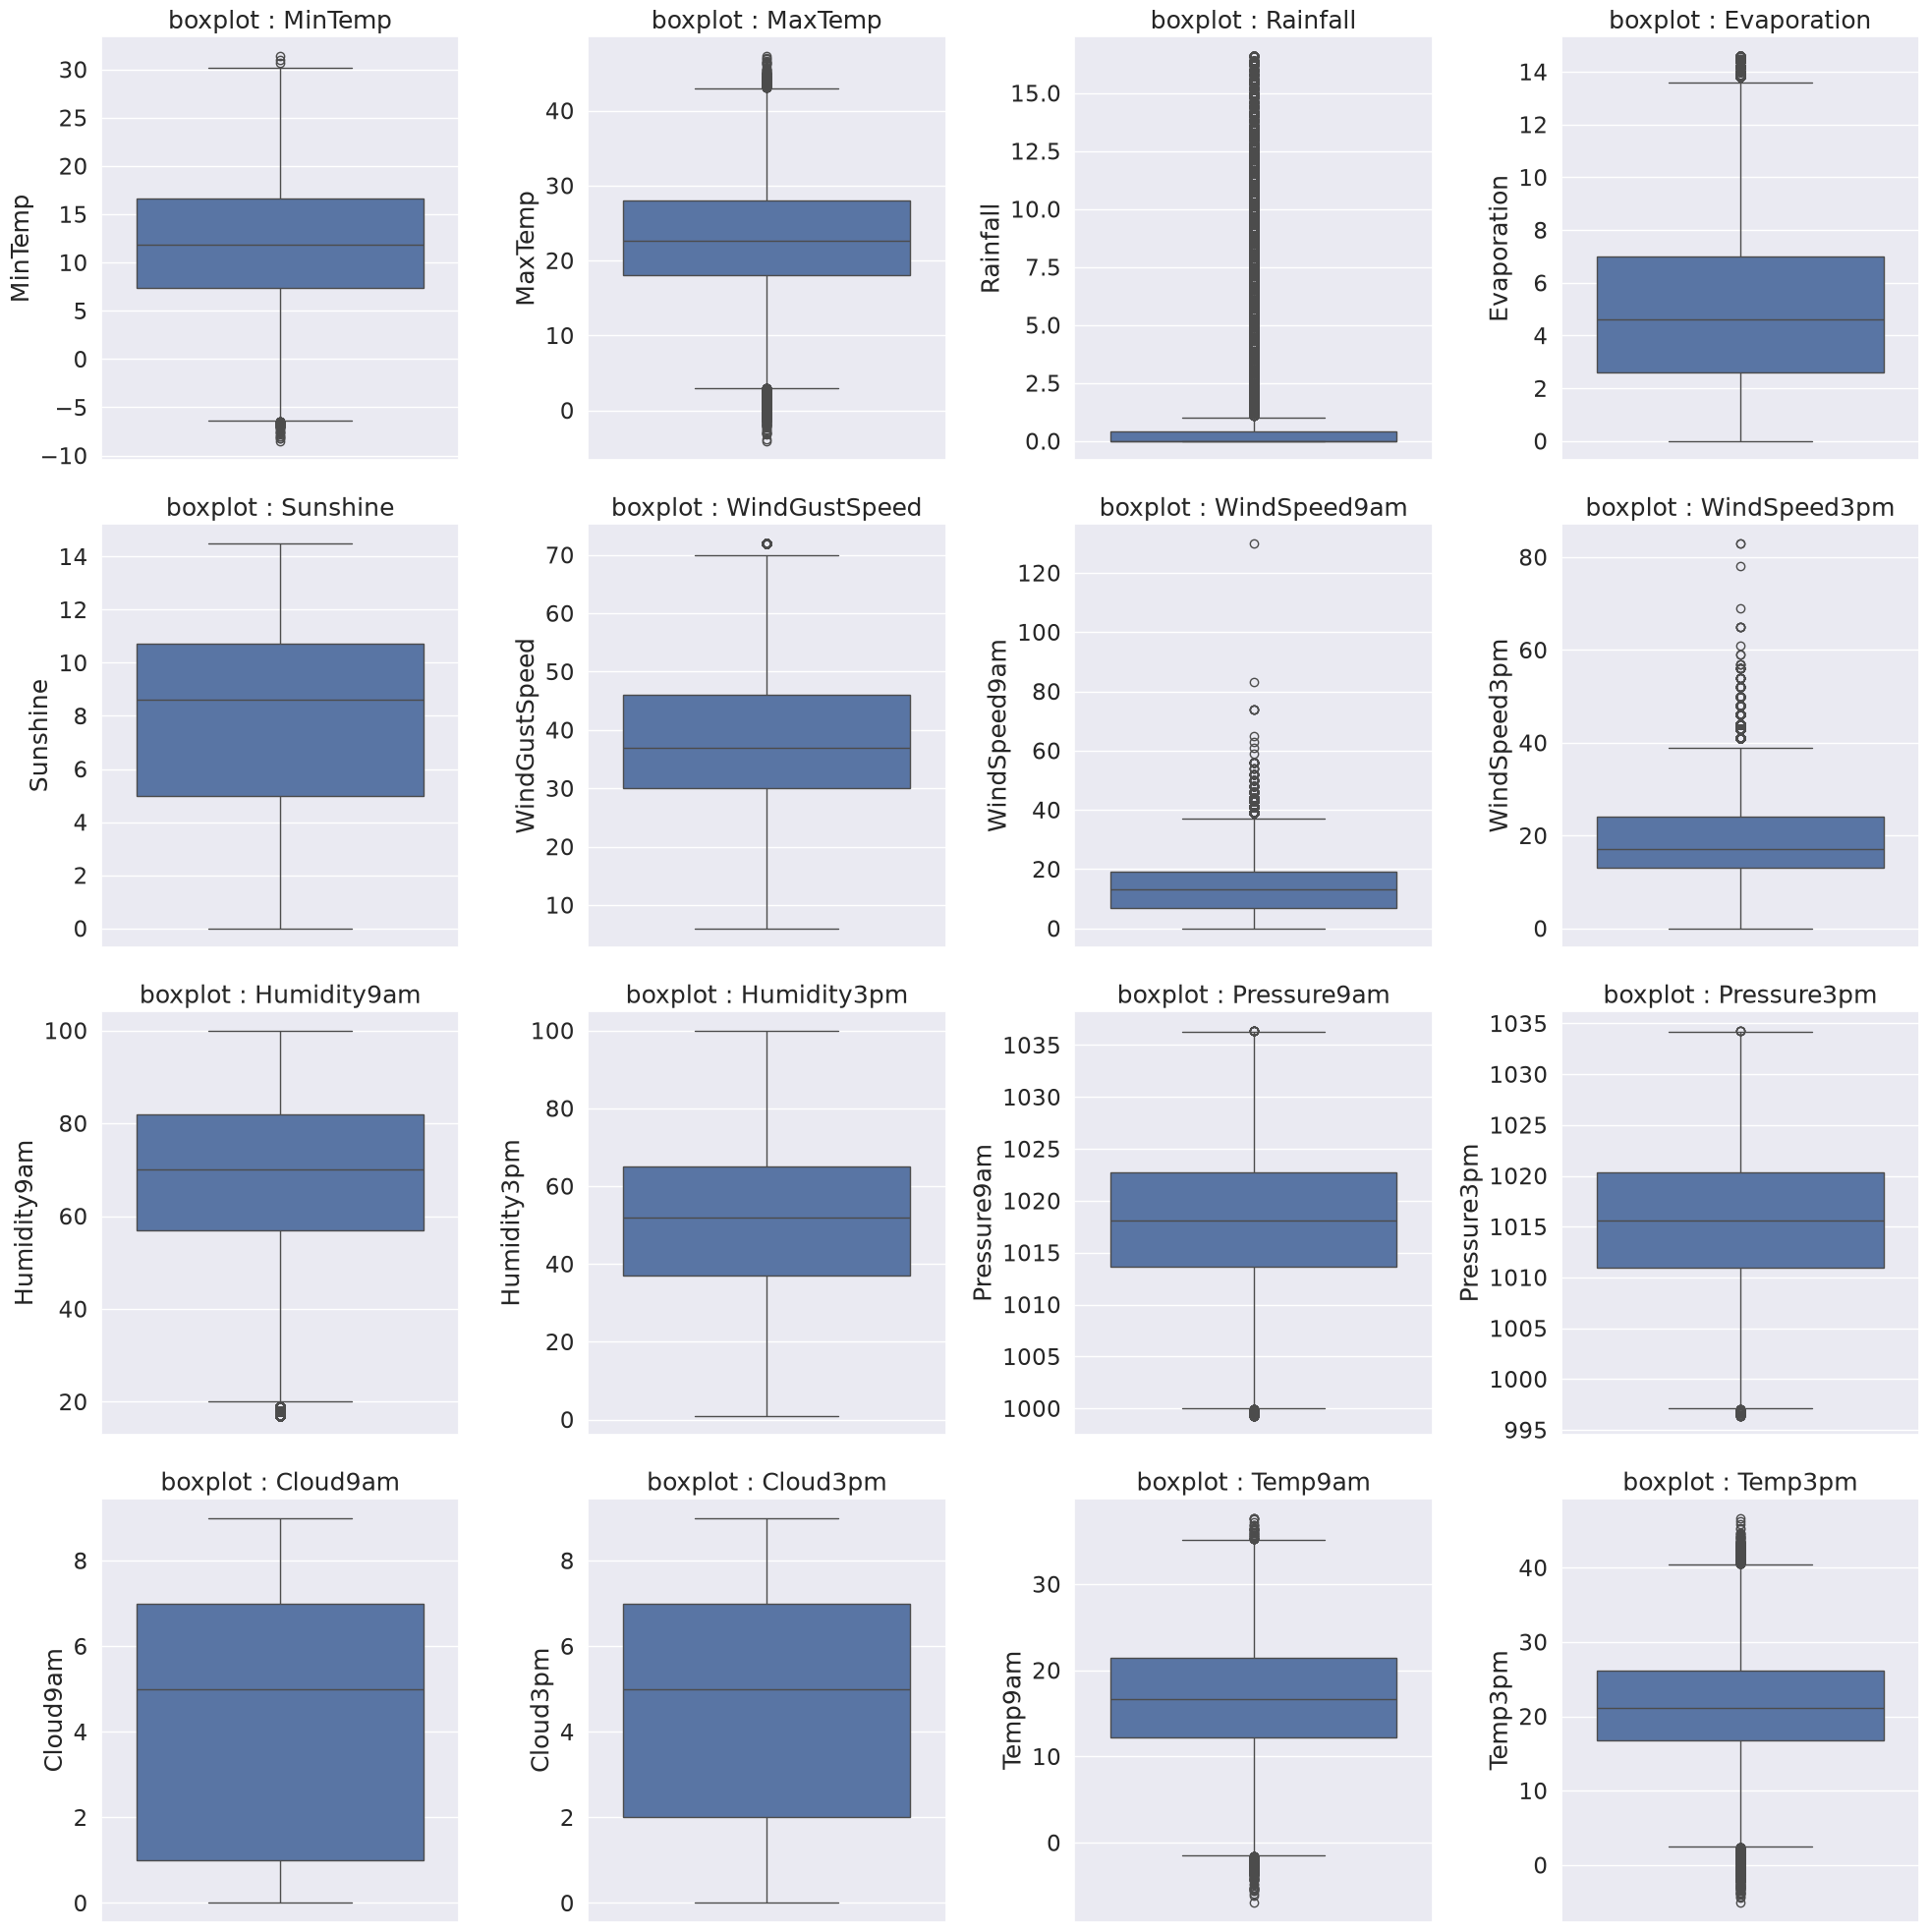

In [36]:
# 이상치 제거 후 모든 숫자형 열의 분포를 4x4 박스플롯으로 다시 확인
nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20,20) 

axs = axs.flatten()  # axs 2D -> 1D
for i, col in enumerate(num_cols): 
  ax = sns.boxplot(data=df, y=col, ax=axs[i]) 
  ax.set_title("boxplot : " + col)

plt.tight_layout()

- 문제 : 위에서 이상치 제거한 컬럼만 boxplot으로 시각화하기

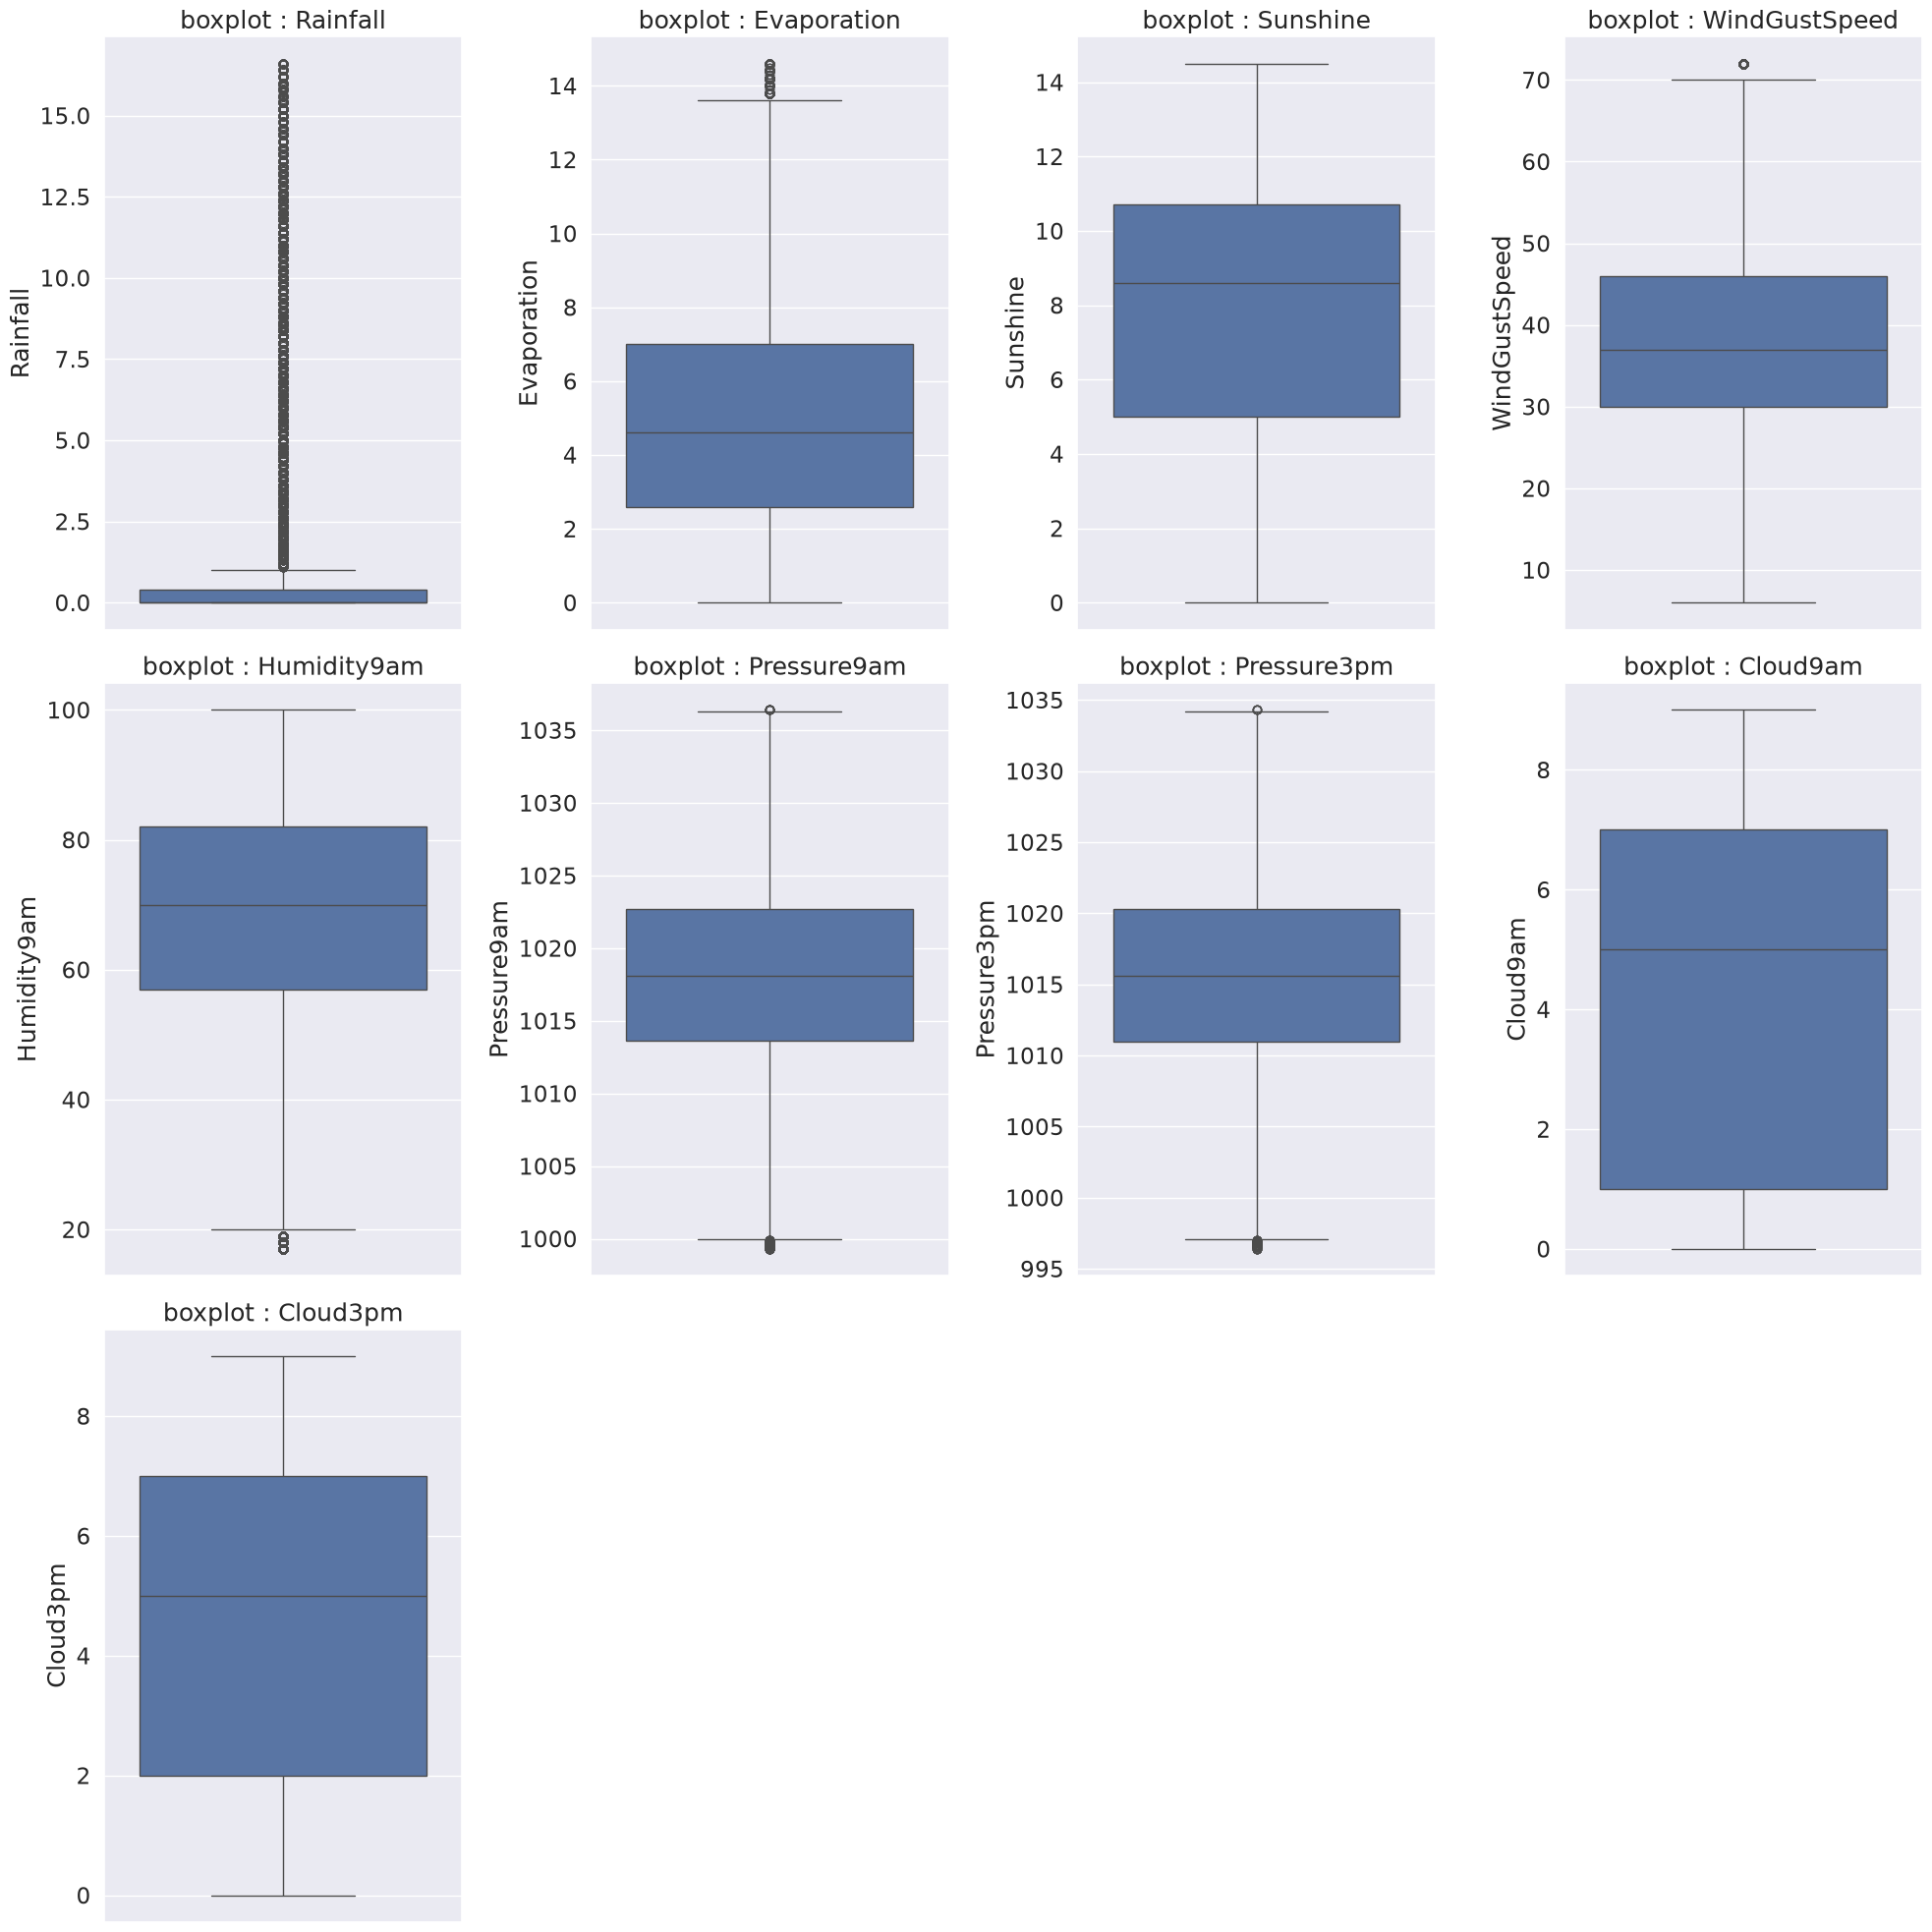

In [37]:
# 이상치 제거 대상이었던 주요 열만 선택해 시각화
outlier_remove_cols = ['Rainfall','Evaporation', 'Sunshine', 'WindGustSpeed','Humidity9am', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm']

# 4x4 fig로 각 fearture들 데이터 분포, 이상치 확인

nrows, ncols = 3, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20,20) 

# 2차원 축 배열을 펼친 후 열별로 박스플롯을 그림
axs = axs.flatten()
for i, col in enumerate(outlier_remove_cols):
    sns.boxplot(data=df, y=col, ax=axs[i])
    axs[i].set_title('boxplot : ' + col)

# 사용하지 않은 나머지 그래프 영역은 숨김
for ax in axs[len(outlier_remove_cols):]:
    ax.set_visible(False)

plt.tight_layout()

## 결측치(null값) 확인 및 처리하기

In [38]:
# 이상치 제거 후 각 열의 결측치 비율을 확인
df.isnull().mean().sort_values()

Date             0.000000
Location         0.000000
MaxTemp          0.008897
MinTemp          0.010560
Temp9am          0.012267
WindSpeed9am     0.012611
Humidity9am      0.018400
WindSpeed3pm     0.021666
RainTomorrow     0.022744
RainToday        0.023478
Rainfall         0.023478
Temp3pm          0.025058
WindDir3pm       0.029829
Humidity3pm      0.031282
WindGustSpeed    0.072786
WindGustDir      0.073220
WindDir9am       0.075931
Pressure3pm      0.105647
Pressure9am      0.105962
Cloud9am         0.389653
Cloud3pm         0.413805
Evaporation      0.437014
Sunshine         0.483640
dtype: float64

### categorical / numerical column 확인하기

In [39]:
# 결측치를 최빈값으로 채울 범주형 열 목록을 확인
print(cat_cols)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


In [40]:
# 결측치를 중앙값으로 채울 숫자형 열 목록을 확인
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


### 결측치 개수 확인하기

In [41]:
# 범주형 열의 결측치 비율을 확인
df[cat_cols].isnull().mean().sort_values()

Date            0.000000
Location        0.000000
RainTomorrow    0.022744
RainToday       0.023478
WindDir3pm      0.029829
WindGustDir     0.073220
WindDir9am      0.075931
dtype: float64

In [42]:
# 숫자형 열의 결측치 비율을 확인
df[num_cols].isnull().mean().sort_values()

MaxTemp          0.008897
MinTemp          0.010560
Temp9am          0.012267
WindSpeed9am     0.012611
Humidity9am      0.018400
WindSpeed3pm     0.021666
Rainfall         0.023478
Temp3pm          0.025058
Humidity3pm      0.031282
WindGustSpeed    0.072786
Pressure3pm      0.105647
Pressure9am      0.105962
Cloud9am         0.389653
Cloud3pm         0.413805
Evaporation      0.437014
Sunshine         0.483640
dtype: float64

In [43]:
# 모든 숫자형 열을 반복하며 결측치를 중앙값으로 채움
for col in num_cols:
    if df[col].isnull().mean()>0:
        col_median=df[col].median()
        df[col] = df[col].fillna(col_median)

In [44]:
# 숫자형 열에 결측치가 남아 있는지 확인
for col in num_cols:
    if df[col].isnull().mean()>0:
        print(col, (df[col].isnull().mean()))

In [45]:
# 바람 방향과 오늘 비 여부의 결측치를 각 열의 최빈값으로 채움
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])
df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])
df['WindDir3pm'] = df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0])
df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])

In [46]:
# 결측치 처리가 적용된 데이터의 앞 5행을 확인
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.6,8.6,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.6,8.6,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.6,8.6,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.6,8.6,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.6,8.6,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [47]:
# 날짜 문자열은 현재 모델의 입력으로 사용하지 않으므로 제거
df = df.drop(['Date'], axis=1)

In [48]:
# Date 열이 제거되었는지 앞 5행을 확인
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.6,8.6,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.6,8.6,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.6,8.6,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.6,8.6,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.6,8.6,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [49]:
# 전처리 후 남은 결측치 비율을 다시 확인
df.isnull().mean().sort_values()

Location         0.000000
MinTemp          0.000000
MaxTemp          0.000000
Rainfall         0.000000
Evaporation      0.000000
Sunshine         0.000000
WindGustDir      0.000000
WindGustSpeed    0.000000
WindDir9am       0.000000
WindDir3pm       0.000000
WindSpeed9am     0.000000
WindSpeed3pm     0.000000
Humidity9am      0.000000
Humidity3pm      0.000000
Pressure9am      0.000000
Pressure3pm      0.000000
Cloud9am         0.000000
Cloud3pm         0.000000
Temp9am          0.000000
Temp3pm          0.000000
RainToday        0.000000
RainTomorrow     0.022744
dtype: float64

### RainTomorrow가 null은 어떻게 처리해야할까?

In [50]:
# 타겟 결측치 제거 전의 데이터 크기를 확인
df.shape

(133529, 22)

In [51]:
# 정답이 없는 행은 지도학습에 사용할 수 없으므로 제거
df = df.dropna(subset=['RainTomorrow'])
df['RainTomorrow']

0         No
1         No
2         No
3         No
4         No
          ..
133523    No
133524    No
133525    No
133526    No
133527    No
Name: RainTomorrow, Length: 130492, dtype: str

In [52]:
# 타겟 결측치 제거 후 남은 결측치 비율을 확인
df.isnull().mean().sort_values()

Location         0.0
MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
Evaporation      0.0
Sunshine         0.0
WindGustDir      0.0
WindGustSpeed    0.0
WindDir9am       0.0
WindDir3pm       0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Cloud9am         0.0
Cloud3pm         0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64

In [53]:
# 타겟 결측치를 제거한 후의 데이터 크기를 확인
df.shape

(130492, 22)

# Yes/No 값에 대한 변환

In [54]:
# 모델이 학습할 수 있도록 비 여부 Yes/No를 1/0으로 변환
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(df['RainToday'].dtype, df['RainTomorrow'].dtype)

int64 int64


## categorical value에 one-hot encoding 적용하기

In [55]:
# 지역과 바람 방향 문자열을 모델이 학습할 수 있는 원-핫 인코딩 열로 변환
df = pd.get_dummies(df, columns = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [56]:
# 범주형 열이 True/False 인코딩 열로 변환되었는지 확인
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.6,8.6,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.6,8.6,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.6,8.6,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.6,8.6,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.6,8.6,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [57]:
# 원-핫 인코딩으로 열이 늘어난 후의 데이터 크기를 확인
df.shape

(130492, 115)

# 트레이닝 데이터 준비

In [58]:
# RainTomorrow를 제외한 모든 열을 예측에 사용할 특징(X)로 설정
X = df.drop(['RainTomorrow'], axis=1)
# 내일 비 여부를 예측할 타겟(y)으로 설정
y = df['RainTomorrow']

In [59]:
# 모델에 넣을 특징 데이터의 앞 5행을 확인
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.6,8.6,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.6,8.6,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.6,8.6,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.6,8.6,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.6,8.6,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [60]:
# 타겟 데이터의 처음 5개 값을 확인
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [61]:
# 데이터를 학습용 80%, 테스트용 20%로 분할
# stratify=y는 두 데이터에서 0/1 비율을 원본과 비슷하게 유지하고 random_state는 결과를 재현함
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2024)

# ML 학습, 테스트, 평가
- 내일 비가 올지 안올지 예측해보기
- 학습기 : Random Forest

## ML 학습

In [62]:
# 정확도 계산 함수와 여러 결정 트리를 종합하는 랜덤 포레스트를 불러옴
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 랜덤 포레스트 분류 모델을 생성하고 학습 데이터로 학습
rf_clf = RandomForestClassifier(random_state=2024, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# 학습된 모델로 테스트 데이터를 예측하고 정확도를 계산
y_pred = rf_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
# baseline - 랜덤 포레스트(Random Forest) Accuracy : 0.8533352086922887
print('랜덤 포레스트(Random Forest) Accuracy (After removing Outlier):', score)

랜덤 포레스트(Random Forest) Accuracy (After removing Outlier): 0.8578489597302579


## ML 모델 평가

In [63]:
# 클래스별 정밀도, 재현율, F1 점수를 확인할 함수를 불러옴
from sklearn.metrics import classification_report
# classification_report() 결과 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92     20784
           1       0.77      0.43      0.55      5315

    accuracy                           0.86     26099
   macro avg       0.82      0.70      0.73     26099
weighted avg       0.85      0.86      0.84     26099



### 문제 XGBoost로 모델 만들고 평가하기

In [64]:
# 앞선 트리의 오류를 다음 트리가 보완하는 XGBoost 분류 모델을 불러옴
from xgboost import XGBClassifier
# xgb_clf = XGBClassifier()
xgb_clf = XGBClassifier(random_state=2024)

# XGBoost를 학습한 후 테스트 데이터를 예측
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('accuracy :', accuracy)

accuracy : 0.8607609486953524


In [65]:
# XGBoost의 클래스별 정밀도, 재현율, F1 점수를 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92     20784
           1       0.73      0.50      0.59      5315

    accuracy                           0.86     26099
   macro avg       0.81      0.73      0.76     26099
weighted avg       0.85      0.86      0.85     26099



## LGBM 분류기

In [66]:
# 큰 데이터를 빠르게 학습하는 LightGBM 분류 모델을 불러옴
from lightgbm import LGBMClassifier
# LightGBM을 생성·학습한 후 테스트 데이터를 예측
lgbm_clf = LGBMClassifier(random_state=2024)
lgbm_clf.fit(X_train, y_train)
y_pred = lgbm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('accuracy :', accuracy)

[LightGBM] [Info] Number of positive: 21257, number of negative: 83136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2414
[LightGBM] [Info] Number of data points in the train set: 104393, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203625 -> initscore=-1.363792
[LightGBM] [Info] Start training from score -1.363792
accuracy : 0.8594965324341929


In [67]:
# LightGBM의 클래스별 정밀도, 재현율, F1 점수를 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92     20784
           1       0.74      0.48      0.58      5315

    accuracy                           0.86     26099
   macro avg       0.81      0.72      0.75     26099
weighted avg       0.85      0.86      0.85     26099

